# Adaptive Boosting (AdaBoost) & Gradient Boosting — A Hands-On Tutorial

**A step-by-step guide with worked numerical examples and complete Python implementations**

---

Boosting is one of the most powerful ideas in machine learning. The winning entries of countless
Kaggle competitions and a huge share of production tabular-ML systems are boosted tree ensembles
(XGBoost, LightGBM, CatBoost). Yet the core idea is simple enough to work out with a pencil.

This notebook teaches the two foundational boosting algorithms:

1. **AdaBoost** (Adaptive Boosting, Freund & Schapire, 1995) — re-weights *training samples*.
2. **Gradient Boosting** (Friedman, 1999/2001) — fits new models to the *residual errors* (gradients).

For each we cover: **intuition → the algorithm step by step → a fully worked numerical example →
from-scratch Python → the scikit-learn version.**

> **How to use this notebook:** run the cells top to bottom (`Shift+Enter`). Every number printed
> by the code matches the hand-worked examples in the markdown, so you can check the math yourself.


## 0. The big idea: turn weak learners into a strong learner

A **weak learner** is a model only slightly better than random guessing — the classic example is a
**decision stump**, a decision tree with a single split.

Boosting builds a strong model as a **weighted sum of many weak learners, trained sequentially**:

$$F(x) = \sum_{m=1}^{M} \alpha_m \, h_m(x)$$

The trick is *how* each new weak learner $h_m$ is chosen. Every boosting algorithm answers one question:

> **"Where is the current ensemble still wrong, and how do I build the next model to fix exactly that?"**

- **AdaBoost** answers by putting more **weight** on the samples that are currently misclassified.
- **Gradient Boosting** answers by fitting the next model to the **residuals** (the negative gradient
  of the loss) — literally "what's left over."

Two knobs are shared by all boosting methods and matter enormously in practice:

| Knob | Symbol | Effect |
|---|---|---|
| Number of rounds | $M$ | More rounds ⇒ lower bias, but eventually overfits |
| Learning rate (shrinkage) | $\nu$ | Smaller ⇒ slower, more robust learning (needs larger $M$) |

Let's set up our tools.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

# Part A — AdaBoost

## A.1 Intuition

Imagine a study group preparing for an exam. After each practice test, the group spends **more time on
the questions they got wrong**. AdaBoost does exactly this with training samples:

1. Start with every sample equally important (equal weights).
2. Train a weak learner; see which samples it gets wrong.
3. **Increase the weight** of the misclassified samples and **decrease** the weight of correct ones.
4. Train the next weak learner on the re-weighted data — it is forced to focus on the hard cases.
5. Give each weak learner a **say ($\alpha$) proportional to how accurate it is**.
6. Final prediction = weighted majority vote.


## A.2 The algorithm, step by step

We use labels $y_i \in \{-1, +1\}$ (this makes the math clean).

**Input:** data $\{(x_i, y_i)\}_{i=1}^{n}$, number of rounds $M$.

**Step 0 — Initialize weights:** $\;w_i^{(1)} = \dfrac{1}{n}$ for all $i$.

**For $m = 1, 2, \dots, M$:**

**Step 1 — Train a weak learner** $h_m(x)$ on the data weighted by $w^{(m)}$.

**Step 2 — Weighted error:**
$$\varepsilon_m = \frac{\sum_{i=1}^{n} w_i^{(m)} \,\mathbb{1}[\,h_m(x_i) \neq y_i\,]}{\sum_{i=1}^{n} w_i^{(m)}}$$

**Step 3 — Learner weight (its "say"):**
$$\alpha_m = \tfrac{1}{2}\ln\!\left(\frac{1-\varepsilon_m}{\varepsilon_m}\right)$$
A near-perfect learner ($\varepsilon \to 0$) gets a large $\alpha$; a coin-flip learner ($\varepsilon = 0.5$)
gets $\alpha = 0$.

**Step 4 — Update sample weights** (then renormalize so they sum to 1):
$$w_i^{(m+1)} = \frac{w_i^{(m)} \, \exp\!\big(-\alpha_m \, y_i \, h_m(x_i)\big)}{Z_m}$$
Because $y_i h_m(x_i) = +1$ when correct and $-1$ when wrong, correct samples are multiplied by
$e^{-\alpha_m}$ (shrunk) and wrong ones by $e^{+\alpha_m}$ (grown). $Z_m$ is the normalizer.

**Output — the strong classifier:**
$$F(x) = \operatorname{sign}\!\left(\sum_{m=1}^{M} \alpha_m \, h_m(x)\right)$$


## A.3 A fully worked numerical example

Ten points on a line, labels not separable by any single stump:

| $x$ | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 |
|---|---|---|---|---|---|---|---|---|---|---|
| $y$ | +1 | +1 | +1 | −1 | −1 | −1 | +1 | +1 | +1 | −1 |

The middle block (4–6) and the last point (10) are negative; everything else is positive. **No single
threshold can separate these**, so we truly need boosting. Our weak learners are decision stumps of the
form *"predict +1 on one side of a threshold, −1 on the other."*


In [2]:
X = np.array([1,2,3,4,5,6,7,8,9,10], dtype=float)
y = np.array([1,1,1,-1,-1,-1,1,1,1,-1], dtype=float)
n = len(X)

def best_stump(X, y, w):
    """Return the decision stump (threshold + polarity) with lowest weighted error."""
    best = None
    thresholds = [X.min()-0.5] + [(X[i]+X[i+1])/2 for i in range(n-1)] + [X.max()+0.5]
    for thr in thresholds:
        for pol in (+1, -1):                      # pol=+1: '+1 if x<thr'; pol=-1: '+1 if x>=thr'
            pred = np.where((X < thr) if pol == 1 else (X >= thr), 1.0, -1.0)
            err = np.sum(w[pred != y])            # weighted error (weights already sum to 1)
            if best is None or err < best['err']:
                best = dict(thr=thr, pol=pol, err=err, pred=pred)
    return best

### Round 1

All weights equal: $w_i = 0.1$. The best stump is **"predict +1 if $x < 3.5$, else −1."**
It misclassifies points 7, 8, 9 (which are +1 but fall on the −1 side).

$$\varepsilon_1 = 3 \times 0.1 = 0.30, \qquad
\alpha_1 = \tfrac{1}{2}\ln\frac{0.7}{0.3} = 0.4236$$

**Weight update.** Correct samples: $0.1\,e^{-0.4236} = 0.0655$. Wrong samples (7,8,9):
$0.1\,e^{+0.4236} = 0.1528$. Normalizer $Z_1 = 7(0.0655) + 3(0.1528) = 0.9165$. After dividing:
correct → **0.0714**, wrong → **0.1667**. The three hard points are now the heaviest.

### Round 2

With the new weights, the best stump is **"predict +1 if $x < 9.5$, else −1"** (it gets points 7,8,9
right, which now matter most). It misclassifies 4, 5, 6.

$$\varepsilon_2 = 3 \times 0.0714 = 0.2143,\qquad \alpha_2 = \tfrac12\ln\frac{0.7857}{0.2143}=0.6496$$

### Round 3

The best stump is now **"predict +1 if $x \ge 6.5$, else −1."** It misclassifies 1, 2, 3, 10.

$$\varepsilon_3 = 0.1818,\qquad \alpha_3 = 0.7520$$

### Combine — the weighted vote

$$F(x) = \operatorname{sign}\big(0.4236\,h_1 + 0.6496\,h_2 + 0.7520\,h_3\big)$$

Check point $x=7$: $h_1=-1,\ h_2=+1,\ h_3=+1 \Rightarrow F = -0.4236+0.6496+0.7520 = +0.978 \Rightarrow +1$ ✓
Check point $x=1$: $h_1=+1,\ h_2=+1,\ h_3=-1 \Rightarrow F = 0.4236+0.6496-0.7520 = +0.321 \Rightarrow +1$ ✓

Three stumps — each individually wrong on 30% of the data — combine into a classifier that is **100%
correct**. Let's confirm every number with code.

In [3]:
w = np.ones(n) / n
alphas, stumps, F = [], [], np.zeros(n)

for t in range(1, 4):
    s = best_stump(X, y, w)
    eps = s['err']
    alpha = 0.5 * np.log((1 - eps) / eps)
    rule = f"x < {s['thr']}" if s['pol'] == 1 else f"x >= {s['thr']}"
    wrong = [i+1 for i in range(n) if s['pred'][i] != y[i]]
    print(f"Round {t}: stump '+1 if {rule}'  |  eps={eps:.4f}  alpha={alpha:.4f}  misclassified={wrong}")

    w = w * np.exp(-alpha * y * s['pred'])       # update ...
    w = w / w.sum()                              # ... and renormalize
    print(f"         new weights = {w}")
    F += alpha * s['pred']
    alphas.append(alpha); stumps.append(s)

pred = np.sign(F)
print("\nEnsemble F(x) values :", F)
print("Ensemble predictions  :", pred.astype(int))
print("True labels           :", y.astype(int))
print(f"Training accuracy     : {np.mean(pred == y):.0%}")

Round 1: stump '+1 if x < 3.5'  |  eps=0.3000  alpha=0.4236  misclassified=[7, 8, 9]
         new weights = [0.0714 0.0714 0.0714 0.0714 0.0714 0.0714 0.1667 0.1667 0.1667 0.0714]
Round 2: stump '+1 if x < 9.5'  |  eps=0.2143  alpha=0.6496  misclassified=[4, 5, 6]
         new weights = [0.0455 0.0455 0.0455 0.1667 0.1667 0.1667 0.1061 0.1061 0.1061 0.0455]
Round 3: stump '+1 if x >= 6.5'  |  eps=0.1818  alpha=0.7520  misclassified=[1, 2, 3, 10]
         new weights = [0.125  0.125  0.125  0.1019 0.1019 0.1019 0.0648 0.0648 0.0648 0.125 ]

Ensemble F(x) values : [ 0.3213  0.3213  0.3213 -0.526  -0.526  -0.526   0.978   0.978   0.978
 -0.3213]
Ensemble predictions  : [ 1  1  1 -1 -1 -1  1  1  1 -1]
True labels           : [ 1  1  1 -1 -1 -1  1  1  1 -1]
Training accuracy     : 100%


The printed `eps`, `alpha`, and weight values match the hand calculation exactly, and the ensemble
reaches **100% training accuracy**. Below, marker size is proportional to each sample's weight —
watch the misclassified points grow between rounds.

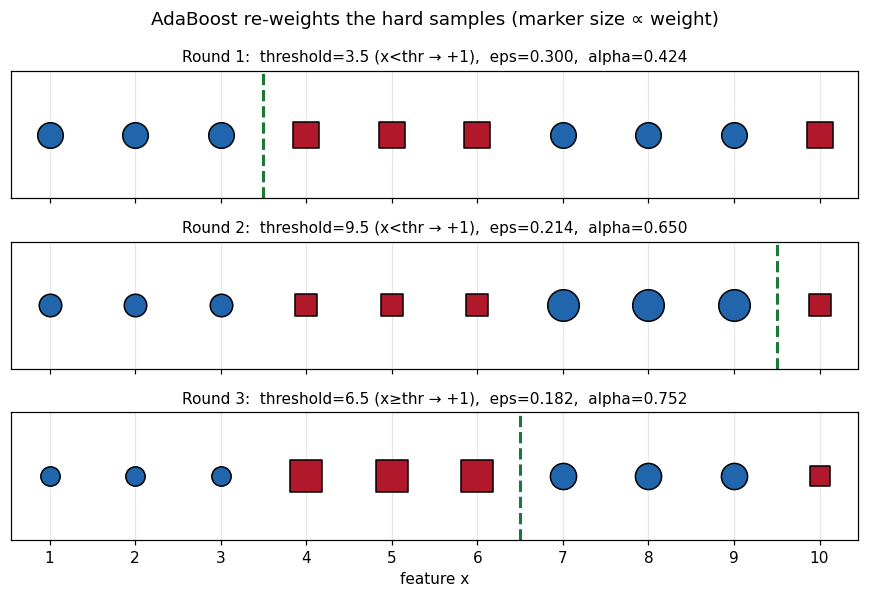

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(8, 5.5), sharex=True)
w = np.ones(n) / n
for t, ax in enumerate(axes):
    s = best_stump(X, y, w)
    eps = s['err']; alpha = 0.5*np.log((1-eps)/eps)
    sizes = 60 + w*2200
    for xi, yi, si in zip(X, y, sizes):
        ax.scatter(xi, 0, s=si, marker='o' if yi>0 else 's',
                   c='#2166ac' if yi>0 else '#b2182b', edgecolors='k', zorder=3)
    ax.axvline(s['thr'], color='#1b7837', ls='--', lw=2)
    side = 'x<thr → +1' if s['pol']==1 else 'x≥thr → +1'
    ax.set_title(f"Round {t+1}:  threshold={s['thr']:.1f} ({side}),  eps={eps:.3f},  alpha={alpha:.3f}",
                 fontsize=10)
    ax.set_yticks([]); ax.set_ylim(-0.5, 0.5)
    w = w*np.exp(-alpha*y*s['pred']); w = w/w.sum()
axes[-1].set_xticks(range(1,11)); axes[-1].set_xlabel('feature x')
fig.suptitle('AdaBoost re-weights the hard samples (marker size ∝ weight)')
plt.tight_layout(); plt.show()

## A.4 AdaBoost from scratch (reusable class)

In [5]:
class AdaBoostStump:
    """Minimal AdaBoost with 1-D decision stumps and {-1,+1} labels."""
    def __init__(self, n_rounds=50):
        self.n_rounds = n_rounds
        self.alphas, self.stumps = [], []

    def _best_stump(self, X, y, w):
        best = None
        col = X.ravel()
        thr_list = [col.min()-0.5] + [(np.sort(col)[i]+np.sort(col)[i+1])/2
                                      for i in range(len(col)-1)] + [col.max()+0.5]
        for thr in thr_list:
            for pol in (+1, -1):
                pred = np.where((col < thr) if pol==1 else (col >= thr), 1.0, -1.0)
                err = np.sum(w[pred != y])
                if best is None or err < best[2]:
                    best = (thr, pol, err, pred)
        return best

    def fit(self, X, y):
        w = np.ones(len(y)) / len(y)
        for _ in range(self.n_rounds):
            thr, pol, eps, pred = self._best_stump(X, y, w)
            eps = np.clip(eps, 1e-10, 1-1e-10)
            alpha = 0.5 * np.log((1-eps)/eps)
            w = w * np.exp(-alpha * y * pred); w /= w.sum()
            self.alphas.append(alpha); self.stumps.append((thr, pol))
            if eps < 1e-10:                      # perfect learner: stop early
                break
        return self

    def decision_function(self, X):
        col = X.ravel(); F = np.zeros(len(col))
        for alpha, (thr, pol) in zip(self.alphas, self.stumps):
            F += alpha * np.where((col < thr) if pol==1 else (col >= thr), 1.0, -1.0)
        return F

    def predict(self, X):
        return np.sign(self.decision_function(X))

model = AdaBoostStump(n_rounds=10).fit(X, y)
print("Rounds actually used:", len(model.alphas))
print("Predictions:", model.predict(X).astype(int))
print(f"Accuracy   : {np.mean(model.predict(X)==y):.0%}")

Rounds actually used: 10
Predictions: [ 1  1  1 -1 -1 -1  1  1  1 -1]
Accuracy   : 100%


## A.5 The scikit-learn version

In practice you would just use scikit-learn. The `SAMME` algorithm is the multi-class generalization of the discrete AdaBoost we derived above.

In [6]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# scikit-learn expects 0/1 labels and a 2-D X
X2d = X.reshape(-1, 1)
y01 = (y > 0).astype(int)

clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),  # decision stump
    n_estimators=10,
    learning_rate=1.0,
    random_state=0,
)
clf.fit(X2d, y01)
print("sklearn predictions:", clf.predict(X2d))
print("true labels        :", y01)
print(f"accuracy           : {clf.score(X2d, y01):.0%}")

sklearn predictions: [1 1 1 0 0 0 1 1 1 0]
true labels        : [1 1 1 0 0 0 1 1 1 0]
accuracy           : 100%


# Part B — Gradient Boosting

## B.1 Intuition

AdaBoost re-weights samples. Gradient Boosting takes a different, more general view:

> **Fit the new model to the errors that remain — the "residuals."**

Start with a simple prediction (e.g. the mean). Look at how far off you are on each point (the
residual $y - F(x)$). Train a small tree to **predict those residuals**, add a shrunken version of it
to your model, and repeat. Each tree nudges the prediction a little closer to the truth.

The deep insight (Friedman): for **squared-error loss**, the residual $y_i - F(x_i)$ is exactly the
**negative gradient** of the loss with respect to the prediction. So "fit the residuals" is really
"take a gradient-descent step — but in the space of *functions* instead of parameters." That is why it
is called *gradient* boosting, and why it extends to any differentiable loss (logistic, Huber, etc.).


## B.2 The algorithm, step by step (regression, squared-error loss)

Loss: $L(y, F) = \tfrac{1}{2}(y - F)^2$, so the negative gradient is $-\partial L/\partial F = (y - F)$ = the residual.

**Step 0 — Initialize** with the best constant (the mean for squared error):
$$F_0(x) = \bar{y}$$

**For $m = 1, 2, \dots, M$:**

**Step 1 — Compute residuals** (pseudo-residuals):
$$r_i^{(m)} = y_i - F_{m-1}(x_i)$$

**Step 2 — Fit a regression tree** $h_m(x)$ to the residuals $\{(x_i, r_i^{(m)})\}$.

**Step 3 — Update** the model with a learning rate $\nu \in (0, 1]$:
$$F_m(x) = F_{m-1}(x) + \nu \, h_m(x)$$

**Output:** $\;F_M(x) = \bar{y} + \nu \sum_{m=1}^{M} h_m(x)$.

The learning rate $\nu$ shrinks each tree's contribution. Small $\nu$ (e.g. 0.1) plus many trees almost
always generalizes better than a few full-strength trees.


## B.3 A fully worked numerical example

Ten points, one feature $x$, continuous target $y$. We use $\nu = 0.5$ and **regression stumps** (one
split, predicting the mean of each side).

| $x$ | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 |
|---|---|---|---|---|---|---|---|---|---|---|
| $y$ | 1.2 | 1.9 | 3.1 | 3.9 | 6.2 | 6.0 | 7.1 | 8.9 | 9.2 | 10.5 |

**Step 0.** $F_0 = \bar{y} = \dfrac{58.0}{10} = 5.8$. Initial $\text{SSE} = \sum (y_i - 5.8)^2 = 92.42$.


In [7]:
x  = np.array([1,2,3,4,5,6,7,8,9,10], dtype=float)
yr = np.array([1.2,1.9,3.1,3.9,6.2,6.0,7.1,8.9,9.2,10.5], dtype=float)
nu = 0.5

def best_reg_stump(x, r):
    """Regression stump minimizing SSE; predicts the mean residual on each side of a split."""
    best = None
    for thr in [(x[i]+x[i+1])/2 for i in range(len(x)-1)]:
        left = x < thr; right = ~left
        pred = np.where(left, r[left].mean(), r[right].mean())
        sse = np.sum((r - pred)**2)
        if best is None or sse < best['sse']:
            best = dict(thr=thr, pred=pred, sse=sse,
                        cl=r[left].mean(), cr=r[right].mean())
    return best

**Round 1.** Residuals $r = y - 5.8 = [-4.6, -3.9, -2.7, -1.9, 0.4, 0.2, 1.3, 3.1, 3.4, 4.7]$.
Best split: $x < 4.5$. Left mean $= -13.1/4 = -3.275$; right mean $= 13.1/6 = +2.183$.
Update: $F_1 = 5.8 + 0.5\,h_1$. For $x=1$: $5.8 + 0.5(-3.275) = 4.1625$. New $\text{SSE} = 38.79$.

**Round 2.** New residuals $r = y - F_1$. Best split: $x < 7.5$ (left mean $-1.132$, right $+2.642$).
$\text{SSE} = 16.36$.

**Round 3.** Best split: $x < 2.5$ (left mean $-2.046$, right $+0.512$). $\text{SSE} = 8.51$.

The training error more than halves at each step: $92.42 \to 38.79 \to 16.36 \to 8.51$. Let's verify.

In [8]:
F = np.full(len(x), yr.mean())
print(f"F0 = mean(y) = {yr.mean():.4f}     SSE = {np.sum((yr-F)**2):.4f}")

for m in range(1, 4):
    r = yr - F                                   # residuals = negative gradient (squared error)
    s = best_reg_stump(x, r)
    F = F + nu * s['pred']                        # shrunken update
    print(f"Round {m}: split x < {s['thr']:.1f}  "
          f"(left={s['cl']:+.3f}, right={s['cr']:+.3f})   "
          f"SSE = {np.sum((yr-F)**2):.4f}")

print("\nFinal F:", F)
print("Target y:", yr)

F0 = mean(y) = 5.8000     SSE = 92.4200
Round 1: split x < 4.5  (left=-3.275, right=+2.183)   SSE = 38.7919
Round 2: split x < 7.5  (left=-1.132, right=+2.642)   SSE = 16.3613
Round 3: split x < 2.5  (left=-2.046, right=+0.512)   SSE = 8.5090

Final F: [2.5732 2.5732 3.8522 3.8522 6.5814 6.5814 6.5814 8.4683 8.4683 8.4683]
Target y: [ 1.2  1.9  3.1  3.9  6.2  6.   7.1  8.9  9.2 10.5]


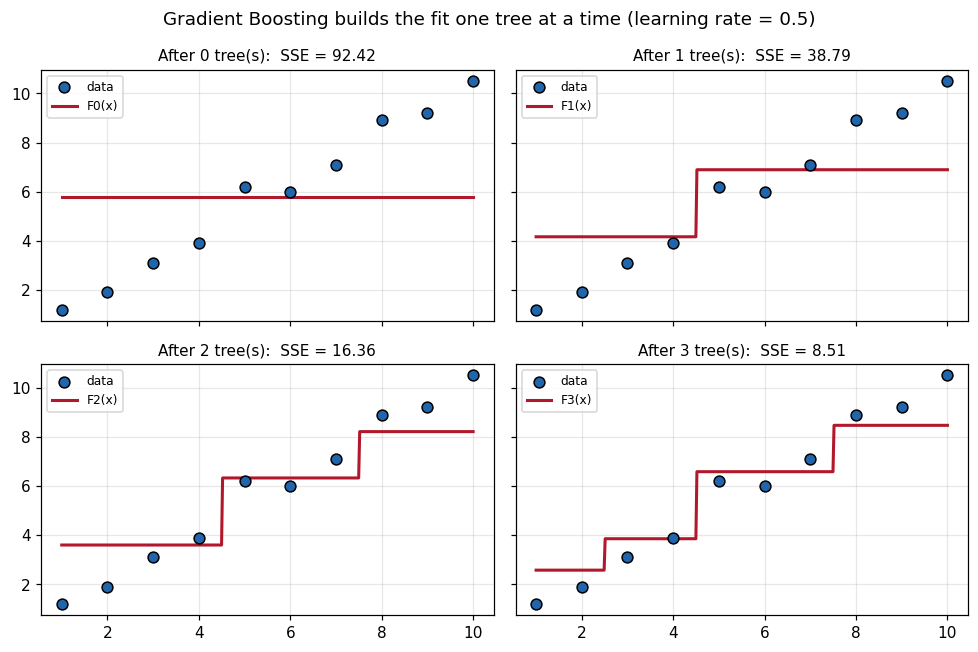

In [9]:
# Visualize the staged fit
xf = np.linspace(1, 10, 400)
fig, axes = plt.subplots(2, 2, figsize=(9, 6), sharex=True, sharey=True)
F = np.full(len(x), yr.mean()); models = []
sse0 = np.sum((yr-F)**2)
stage_sse = [sse0]
for m in range(1, 4):
    r = yr - F; s = best_reg_stump(x, r); models.append(s); F = F + nu*s['pred']
    stage_sse.append(np.sum((yr-F)**2))

for m, ax in enumerate(axes.ravel()):
    ax.scatter(x, yr, c='#2166ac', edgecolors='k', s=50, zorder=3, label='data')
    Ff = np.full(len(xf), yr.mean())
    for k in range(m):
        s = models[k]; Ff = Ff + nu*np.where(xf < s['thr'], s['cl'], s['cr'])
    ax.plot(xf, Ff, color='#b2182b', lw=2, label=f'F{m}(x)')
    ax.set_title(f'After {m} tree(s):  SSE = {stage_sse[m]:.2f}', fontsize=10)
    ax.legend(fontsize=8, loc='upper left')
fig.suptitle('Gradient Boosting builds the fit one tree at a time (learning rate = 0.5)')
plt.tight_layout(); plt.show()

## B.4 Gradient Boosting from scratch (squared-error regression)

In [10]:
from sklearn.tree import DecisionTreeRegressor

class GradientBoostRegressor:
    """Gradient boosting for squared-error loss, using shallow regression trees."""
    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=2):
        self.M = n_estimators; self.nu = learning_rate; self.max_depth = max_depth
        self.trees = []

    def fit(self, X, y):
        self.F0 = y.mean()
        F = np.full(len(y), self.F0)
        for _ in range(self.M):
            residual = y - F                              # negative gradient
            tree = DecisionTreeRegressor(max_depth=self.max_depth)
            tree.fit(X, residual)
            F = F + self.nu * tree.predict(X)
            self.trees.append(tree)
        return self

    def predict(self, X):
        F = np.full(X.shape[0], self.F0)
        for tree in self.trees:
            F += self.nu * tree.predict(X)
        return F

Xr = x.reshape(-1, 1)
gb = GradientBoostRegressor(n_estimators=50, learning_rate=0.3, max_depth=1).fit(Xr, yr)
pred = gb.predict(Xr)
print("Predictions:", pred)
print("Targets    :", yr)
print(f"Final SSE  : {np.sum((yr-pred)**2):.4f}")

Predictions: [ 1.2355  1.8926  3.0921  3.9305  6.0848  6.0016  7.2093  8.8902  9.1955
 10.4678]
Targets    : [ 1.2  1.9  3.1  3.9  6.2  6.   7.1  8.9  9.2 10.5]
Final SSE  : 0.0287


## B.5 The scikit-learn version

In [11]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=50, learning_rate=0.3, max_depth=1, random_state=0
)
gbr.fit(Xr, yr)
pred = gbr.predict(Xr)
print("sklearn predictions:", pred)
print(f"SSE                : {np.sum((yr-pred)**2):.4f}")

sklearn predictions: [ 1.2355  1.8926  3.0921  3.9305  6.0848  6.0016  7.2093  8.8902  9.1955
 10.4678]
SSE                : 0.0287


# Part C — Comparison & practical guidance

## C.1 AdaBoost vs. Gradient Boosting

| | **AdaBoost** | **Gradient Boosting** |
|---|---|---|
| Core mechanism | Re-weights **samples** (hard ones get heavier) | Fits new tree to **residuals / negative gradient** |
| Loss function | Exponential loss (implicitly) | **Any** differentiable loss (squared, logistic, Huber…) |
| How trees combine | Weighted majority vote, weight $\alpha_m$ | Additive, shrunk by learning rate $\nu$ |
| Typical weak learner | Decision **stump** (depth 1) | Shallow tree (depth 2–8) |
| Sensitivity to noise/outliers | **High** (exponential loss over-weights them) | Lower, especially with robust losses |
| Key hyperparameters | `n_estimators`, `learning_rate` | `n_estimators`, `learning_rate`, `max_depth`, subsampling |
| Modern descendants | — | **XGBoost, LightGBM, CatBoost** |

**Rule of thumb:** reach for gradient boosting (or XGBoost/LightGBM) first — it is more flexible and
usually more accurate. AdaBoost remains a beautifully simple mental model and works well on clean data.

## C.2 The learning-rate / n_estimators trade-off

Let's see the two knobs interact on a real dataset.

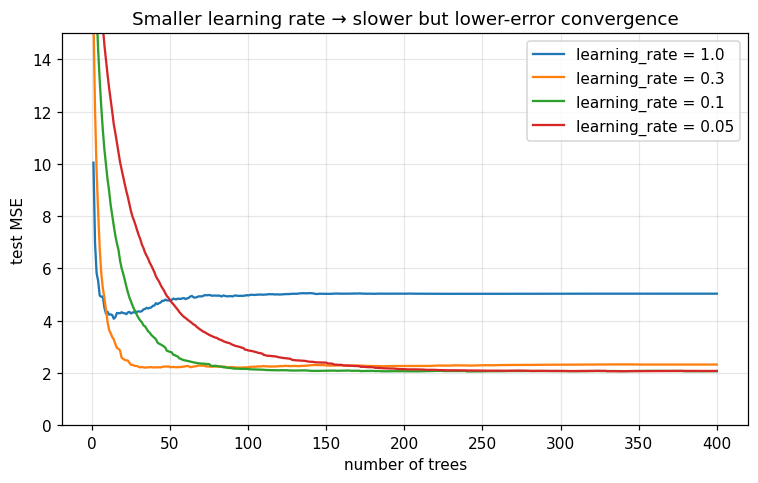

In [12]:
from sklearn.datasets import make_friedman1
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

Xd, yd = make_friedman1(n_samples=1200, noise=1.0, random_state=42)
Xtr, Xte, ytr, yte = train_test_split(Xd, yd, test_size=0.3, random_state=42)

plt.figure(figsize=(7, 4.5))
for lr in [1.0, 0.3, 0.1, 0.05]:
    g = GradientBoostingRegressor(n_estimators=400, learning_rate=lr,
                                  max_depth=3, random_state=0).fit(Xtr, ytr)
    # staged_predict lets us read test error after each added tree
    test_err = [mean_squared_error(yte, p) for p in g.staged_predict(Xte)]
    plt.plot(range(1, 401), test_err, label=f'learning_rate = {lr}')
plt.xlabel('number of trees'); plt.ylabel('test MSE')
plt.title('Smaller learning rate → slower but lower-error convergence')
plt.legend(); plt.ylim(0, 15); plt.tight_layout(); plt.show()

**What to notice:**

- A large learning rate (1.0) drops fast but plateaus higher and can start to over-fit.
- Small learning rates (0.05–0.1) need more trees but reach a **lower** test error — this is why
  `learning_rate ≈ 0.05–0.1` with several hundred trees is a common default.
- The classic recipe: **set a small learning rate, then use early stopping** to pick `n_estimators`.

## C.3 Practical checklist

1. **Start** with `GradientBoostingRegressor/Classifier` (or `XGBoost`/`LightGBM` for larger data).
2. **Tune in this order:** `learning_rate` (small), `n_estimators` (via early stopping),
   `max_depth` (3–6), then subsampling / regularization.
3. **Scale of features doesn't matter** for tree-based boosting — no need to standardize.
4. **Watch for overfitting:** monitor a validation curve; more trees is *not* always better.
5. **Noisy labels?** Prefer gradient boosting with a robust loss (`huber`) over AdaBoost.

## Summary

- **Boosting** turns many weak learners into one strong learner by training them **sequentially**,
  each fixing the previous ensemble's mistakes.
- **AdaBoost** re-weights *samples*; the weight $\alpha_m = \tfrac12\ln\frac{1-\varepsilon_m}{\varepsilon_m}$
  gives accurate learners more say. Our 3-stump example reached 100% accuracy on data no single stump
  could split.
- **Gradient Boosting** fits each new tree to the *residuals* (the negative gradient), generalizing to
  any differentiable loss. Our example cut SSE from 92.4 to 8.5 in three tiny trees.
- The **learning rate** and **number of trees** are the levers that trade off speed, accuracy, and
  overfitting.

*You now have both the intuition and working code — try swapping in your own dataset above.*